In [1]:
print("It works!")

It works!


In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')

Matplotlib is building the font cache; this may take a moment.


In [9]:
df = pd.read_excel('student_data_csv.xlsx')
print(f'Dataset: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'student_data_csv.xlsx'

In [10]:
import os
print(os.getcwd())

C:\Users\Munther.Hassan


In [11]:
df = pd.read_excel('student_data_csv.xlsx')
print(f'Dataset: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'student_data_csv.xlsx'

In [12]:
[f for f in os.listdir() if 'student' in f.lower()]

['student_analysis.ipynb', 'student_data.csv.xlsx']

In [13]:
df = pd.read_excel('student_data.csv.xlsx')
print(f'Dataset: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

Dataset: 395 rows, 33 columns


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [14]:
df[['studytime', 'absences', 'G1', 'G2', 'G3']].describe().round(2)

,studytime,absences,G1,G2,G3
count,395.00,395.00,395.00,395.00,395.00
mean,2.04,5.71,10.91,10.71,10.42
std,0.84,8.00,3.32,3.76,4.58
min,1.00,0.00,3.00,0.00,0.00
25%,1.00,0.00,8.00,9.00,8.00
50%,2.00,4.00,11.00,11.00,11.00
75%,2.00,8.00,13.00,13.00,14.00
max,4.00,75.00,19.00,19.00,20.00


In [15]:
study_labels = {1: '<2 hrs', 2: '2-5 hrs', 3: '5-10 hrs', 4: '>10 hrs'}
df['study_label'] = df['studytime'].map(study_labels)

df.groupby('study_label')['G3'].mean().reindex(study_labels.values()).round(2)

study_label
<2 hrs      10.05
2-5 hrs     10.17
5-10 hrs    11.40
>10 hrs     11.26
Name: G3, dtype: float64

In [16]:
df['study_label'].value_counts().reindex(study_labels.values())

study_label
<2 hrs      105
2-5 hrs     198
5-10 hrs     65
>10 hrs      27
Name: count, dtype: int64

C:\Users\Munther.Hassan\AppData\Local\Temp\ipykernel_16972\4195645226.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='study_label', y='G3', order=order, palette='Blues', ax=axes[0])


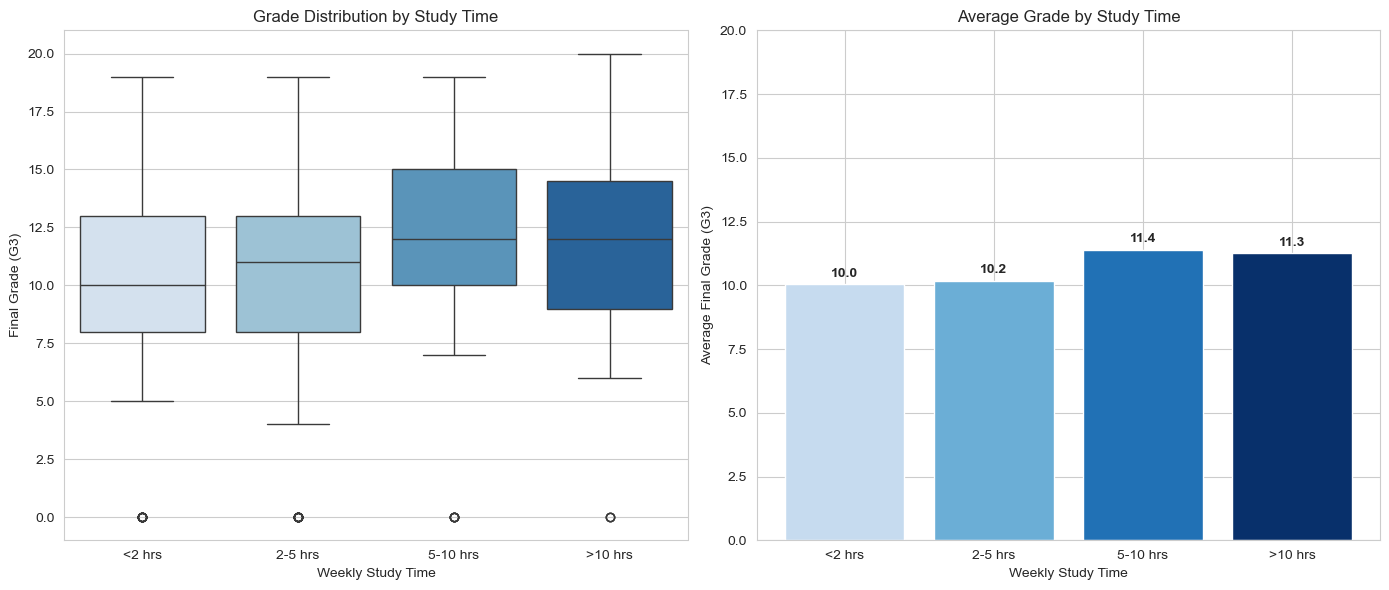

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

order = ['<2 hrs', '2-5 hrs', '5-10 hrs', '>10 hrs']

# Left: boxplot showing the full distribution
sns.boxplot(data=df, x='study_label', y='G3', order=order, palette='Blues', ax=axes[0])
axes[0].set_xlabel('Weekly Study Time')
axes[0].set_ylabel('Final Grade (G3)')
axes[0].set_title('Grade Distribution by Study Time')

# Right: bar chart of averages
avg = df.groupby('study_label')['G3'].mean().reindex(order)
bars = axes[1].bar(order, avg, color=['#c6dbef', '#6baed6', '#2171b5', '#08306b'])
axes[1].set_xlabel('Weekly Study Time')
axes[1].set_ylabel('Average Final Grade (G3)')
axes[1].set_title('Average Grade by Study Time')
axes[1].set_ylim(0, 20)

for bar in bars:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., h + 0.3, f'{h:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [18]:
bins = [0, 3, 7, 15, 75]
labels = ['Low (0-3)', 'Moderate (4-7)', 'High (8-15)', 'Very High (16+)']
df['absence_group'] = pd.cut(df['absences'], bins=bins, labels=labels, include_lowest=True)

df.groupby('absence_group', observed=True)['G3'].agg(['mean', 'count']).round(2)

,mean,count
absence_group,,
Low (0-3),9.82,191
Moderate (4-7),11.50,96
High (8-15),10.71,75
Very High (16+),10.03,33


In [19]:
print('Students with G3 = 0:', (df['G3'] == 0).sum())
print('\nTheir absence groups:')
print(df[df['G3'] == 0]['absence_group'].value_counts())

Students with G3 = 0: 38

Their absence groups:
absence_group
Low (0-3)          38
Moderate (4-7)      0
High (8-15)         0
Very High (16+)     0
Name: count, dtype: int64


In [20]:
df_clean = df[df['G3'] > 0]
print(f'Removed {len(df) - len(df_clean)} students with G3 = 0')
print(f'Remaining: {len(df_clean)} students\n')

df_clean.groupby('absence_group', observed=True)['G3'].agg(['mean', 'count']).round(2)

Removed 38 students with G3 = 0
Remaining: 357 students



,mean,count
absence_group,,
Low (0-3),12.26,153
Moderate (4-7),11.50,96
High (8-15),10.71,75
Very High (16+),10.03,33


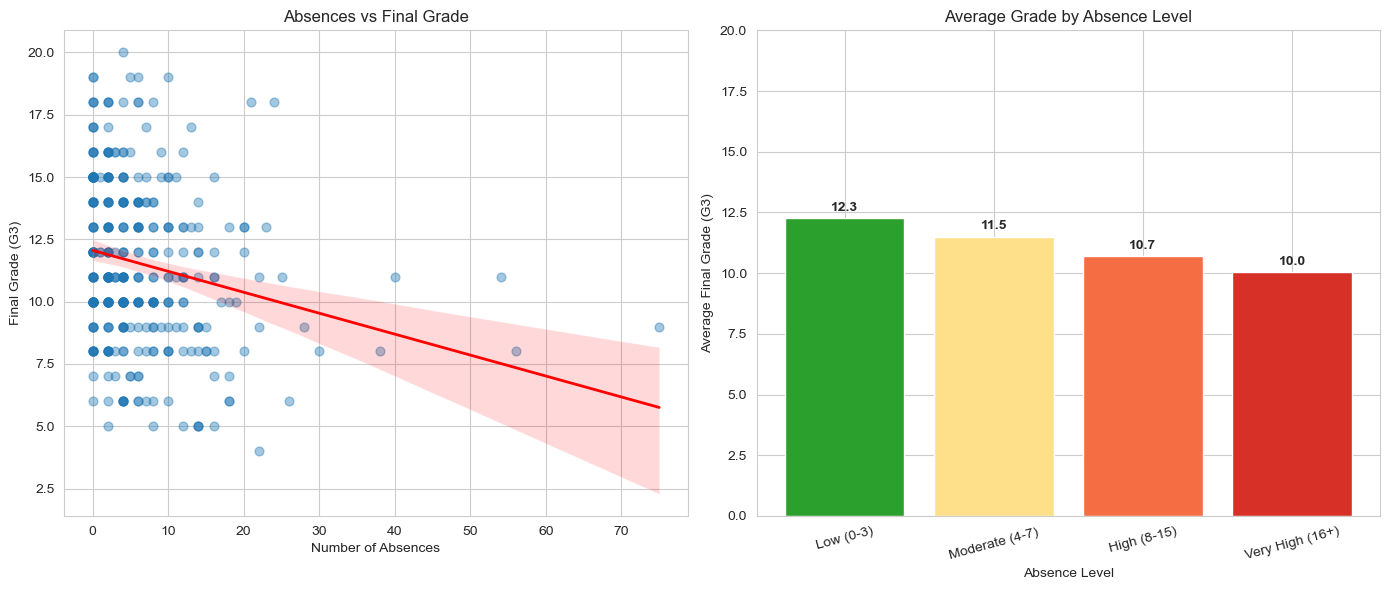

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: scatter plot with trend line
sns.regplot(data=df_clean, x='absences', y='G3',
            scatter_kws={'alpha': 0.4, 's': 40},
            line_kws={'color': 'red', 'linewidth': 2}, ax=axes[0])
axes[0].set_xlabel('Number of Absences')
axes[0].set_ylabel('Final Grade (G3)')
axes[0].set_title('Absences vs Final Grade')

# Right: bar chart by absence group
colors = ['#2ca02c', '#fee08b', '#f46d43', '#d73027']
avg = df_clean.groupby('absence_group', observed=True)['G3'].mean()
bars = axes[1].bar(range(len(avg)), avg.values, color=colors)
axes[1].set_xticks(range(len(avg)))
axes[1].set_xticklabels(labels, rotation=15)
axes[1].set_xlabel('Absence Level')
axes[1].set_ylabel('Average Final Grade (G3)')
axes[1].set_title('Average Grade by Absence Level')
axes[1].set_ylim(0, 20)

for bar in bars:
    h = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., h + 0.3, f'{h:.1f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## Key Findings

### Question 1: Does study time improve performance?
- Students who study 5-10 hours/week score the highest on average (11.4), 
  about 1.4 points above those who study less than 2 hours (10.0).
- However, studying more than 10 hours doesn't guarantee better results (11.3), 
  possibly because those students are struggling and compensating with extra effort.
- The sample size for the >10 hrs group is small (27 students), 
  so this finding should be interpreted cautiously.

### Question 2: Do absences affect performance?
- There is a clear negative relationship: students with low absences (0-3) 
  average 12.3, while those with very high absences (16+) average 10.0.
- An important data cleaning step was needed: 38 students scored 0 on G3 
  (likely dropouts), which initially distorted the results.

### What I learned
- Always check your sample sizes before drawing conclusions.
- Unexpected results are worth investigating — they often reveal data quality issues.
- Correlation does not mean causation: these patterns suggest relationships 
  but don't prove that absences *cause* lower grades.